# Data Mining II — Donor Response Classification
## v8: sklearn-only F1 optimization, stronger predictive signal and overfitting control

This version adapts the completed project with three explicit goals:

1. **Increase predictive signal** through audited cleaning and behavior-oriented feature engineering.
2. **Increase F1-score** through threshold-aware validation rather than fixed 0.50 classification.
3. **Reduce overfitting** through regularized hyperparameter spaces, out-of-fold validation and train/test gap diagnostics.

All benchmarking, tuning and final model selection are implemented with **vanilla scikit-learn only**.


## 0. Diagnosis of the previous notebook

The previous notebook already had useful elements: train/validation/internal-test separation, F1 as the main metric, several sklearn candidate models, threshold tuning and an advanced extension.

The main issues to correct are:

- **Model selection was too dependent on a single validation split.** This can make the selected threshold and model unstable.
- **Several tuning sections were repeated manually**, increasing maintenance risk and making it harder to compare models fairly.
- **Some models were allowed to optimize Recall very aggressively**, producing many positive predictions and lower Precision.
- **Overfitting was diagnosed after selection**, but not directly penalized during model selection.
- **Feature engineering was present but not fully integrated as the main modeling table.**
- **The final selection should be driven by out-of-fold F1, Precision, Recall and overfitting gap**, not only by the highest validation F1.

This notebook refactors the project into a single reproducible sklearn workflow.


In [0]:
# Core imports
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing and model selection
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid, cross_val_predict

# Scikit-learn: models only
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.calibration import CalibratedClassifierCV

# Scikit-learn: metrics and plots
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
TARGET = 'TARGET_B'
ID_COL = 'CONTROL_NUMBER'

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)


## 1. Load data

The notebook is designed to run both locally and in Databricks/Kaggle-like environments. The training file is the only labeled file used for model development. The independent test file, when available, is used only at the end for prediction generation.


In [0]:
def find_existing_path(candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f'None of these paths exists: {candidates}')

TRAIN_PATH = find_existing_path([
    '/mnt/data/donors_train.csv',
    'donors_train.csv',
    '/dbfs/FileStore/donors_train.csv'
])

TEST_PATH_CANDIDATES = [
    '/mnt/data/donors_test.csv',
    'donors_test.csv',
    '/dbfs/FileStore/donors_test.csv'
]

train_df_raw = pd.read_csv(TRAIN_PATH)
print('Train path:', TRAIN_PATH)
print('Shape:', train_df_raw.shape)
display(train_df_raw.head())


Train path: donors_train.csv
Shape: (13560, 41)


CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.03713229226065,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.0,17.5,null,0.0,2.0,0.154,0.0,2,T,null,1
112703,3.0,2.0,null,F,1.0,1.0,U,null,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.0,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.0,15.0,1.0,0.25,1.0,0.1,0.0,3,R,null,1
166437,4.0,2.0,null,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.0,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.0,10.67,0.0,0.0,3.0,0.231,1.0,1,U,null,0
170621,4.0,null,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.0,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.0,10.0,2.0,0.286,2.0,0.111,0.0,1,U,null,0
44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.0,17.0,17.0,13.0,0.0,52.0,null,66.0,90.0,1.0,15008.0,N,5.67,5.4,3.0,0.6,5.0,0.5,0.0,2,C,null,0


## 2. Target and business-oriented EDA

The goal is not to produce many charts. The objective is to identify signals that can improve classification of future donors.


In [0]:
def target_summary(df, target=TARGET):
    out = (
        df[target]
        .value_counts(dropna=False)
        .rename_axis('target')
        .reset_index(name='records')
    )
    out['rate'] = out['records'] / len(df)
    return out

display(target_summary(train_df_raw))


target,records,rate
0,10170,0.75
1,3390,0.25


In [0]:
def donation_rate_by_quantile(df, feature, target=TARGET, q=5):
    tmp = df[[feature, target]].copy()
    tmp = tmp.dropna(subset=[feature])
    if tmp[feature].nunique() <= 1:
        return pd.DataFrame()
    tmp['bin'] = pd.qcut(tmp[feature], q=q, duplicates='drop')
    return (
        tmp.groupby('bin', observed=True)
        .agg(records=(target, 'size'), donor_rate=(target, 'mean'), feature_mean=(feature, 'mean'))
        .reset_index()
    )

business_signal_vars = [
    'RECENT_RESPONSE_COUNT',
    'RECENT_CARD_RESPONSE_COUNT',
    'FREQUENCY_STATUS_97NK',
    'RECENT_RESPONSE_PROP',
    'FILE_CARD_GIFT',
    'LIFETIME_GIFT_COUNT',
    'MONTHS_SINCE_LAST_GIFT',
    'LAST_GIFT_AMT',
    'RECENT_AVG_GIFT_AMT'
]

for col in [c for c in business_signal_vars if c in train_df_raw.columns]:
    print('\n', '=' * 90)
    print(col)
    display(donation_rate_by_quantile(train_df_raw, col))



RECENT_RESPONSE_COUNT


bin,records,donor_rate,feature_mean
"List(-3.25, 1.0)",3212,0.18711083437110834,0.8550869790486599
"List(1.0, 2.0)",3387,0.21110126956008268,2.0
"List(2.0, 3.0)",2313,0.26026805015131865,3.0
"List(3.0, 5.0)",2764,0.30499276410998555,4.387481910274964
"List(5.0, 16.0)",1615,0.3492260061919505,7.367847379725605



RECENT_CARD_RESPONSE_COUNT


bin,records,donor_rate,feature_mean
"List(-3.6959999999999997, 0.0)",2707,0.18396749168821575,-0.09418917113377429
"List(0.0, 1.0)",4393,0.21875711358980196,1.0
"List(1.0, 2.0)",2901,0.2619786280592899,2.0
"List(2.0, 3.0)",1597,0.30995616781465246,3.0
"List(3.0, 9.0)",1696,0.3584905660377358,4.918342657642333



FREQUENCY_STATUS_97NK


...

bin,records,donor_rate,feature_mean
"List(3.999, 16.0)",3755,0.29507323568575233,13.84298038267547
"List(16.0, 17.0)",1719,0.2745782431646306,17.0
"List(17.0, 18.0)",2734,0.232626188734455,18.0
"List(18.0, 21.0)",2773,0.22069960331770647,19.910566173818967
"List(21.0, 30.29)",2311,0.20986585893552576,24.443666199840884



LAST_GIFT_AMT


bin,records,donor_rate,feature_mean
"List(-21.835, 10.0)",4202,0.311994288434079,7.364164401910776
"List(10.0, 15.0)",3447,0.2512329561937917,14.160324920220482
"List(15.0, 16.0)",426,0.22300469483568075,15.999413145539906
"List(16.0, 20.0)",2629,0.20730315709395208,19.49657664511221
"List(20.0, 450.0)",2595,0.19691714836223506,32.16022258786313



RECENT_AVG_GIFT_AMT


bin,records,donor_rate,feature_mean
"List(-16.818, 9.0)",2797,0.3228459063282088,5.667023068412388
"List(9.0, 12.5)",2833,0.2703847511471938,10.916237204376985
"List(12.5, 15.0)",2660,0.23157894736842105,14.35204887218045
"List(15.0, 20.0)",2676,0.22010463378176381,18.32662556053812
"List(20.0, 260.0)",2326,0.1943250214961307,30.425127303595378


In [0]:
def categorical_signal(df, feature, target=TARGET, min_records=30):
    tmp = (
        df.assign(_cat=df[feature].astype('object').fillna('Missing'))
        .groupby('_cat')
        .agg(records=(target, 'size'), donor_rate=(target, 'mean'))
        .reset_index()
        .query('records >= @min_records')
        .sort_values('donor_rate', ascending=False)
    )
    return tmp

categorical_signal_vars = ['RECENCY_STATUS_96NK', 'HOME_OWNER', 'SES', 'URBANICITY', 'DONOR_GENDER']
for col in [c for c in categorical_signal_vars if c in train_df_raw.columns]:
    print('\n', '=' * 90)
    print(col)
    display(categorical_signal(train_df_raw, col))



RECENCY_STATUS_96NK


_cat,records,donor_rate
S,2887,0.3255975060616557
E,284,0.30633802816901406
A,8188,0.2351001465559355
Missing,262,0.22900763358778625
N,830,0.22771084337349398
L,58,0.1896551724137931
F,1051,0.16936251189343482



HOME_OWNER


_cat,records,donor_rate
Missing,286,0.2727272727272727
H,7233,0.25673994193280797
U,6041,0.24085416321801026



SES


_cat,records,donor_rate
1,4082,0.26531112199902007
2,6380,0.2567398119122257
?,297,0.25252525252525254
3,2274,0.218117854001759
Missing,273,0.1978021978021978
4,254,0.1732283464566929



URBANICITY


_cat,records,donor_rate
S,3117,0.26692332370869426
T,2728,0.2631964809384164
?,296,0.26013513513513514
C,2737,0.24662038728534894
U,1674,0.24074074074074073
R,2739,0.2289156626506024
Missing,269,0.21561338289962825



DONOR_GENDER


_cat,records,donor_rate
U,702,0.2621082621082621
Missing,272,0.2536764705882353
F,7230,0.24965421853388658
M,5356,0.24869305451829724


### EDA conclusion

The strongest business signal is behavioral:

- recent response count,
- recent card response count,
- lifetime gift frequency,
- recency of last gift,
- response rates,
- frequency-recency interaction.

This supports a modeling strategy centered on **RFM + engagement features**, not on pure demographic profiling.


## 3. Data quality audit

The cleaning rules below are deterministic and can be safely applied before the split because they do not learn statistics from the target or from the full feature distribution. Learned operations such as imputation, scaling and feature selection remain inside sklearn pipelines.


In [0]:
def data_quality_report(df):
    rows = []
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        if col == TARGET:
            continue
        s = df[col]
        rows.append({
            'feature': col,
            'missing_rate': s.isna().mean(),
            'min': s.min(),
            'median': s.median(),
            'max': s.max(),
            'negative_count': int((s < 0).sum()) if pd.api.types.is_numeric_dtype(s) else 0,
            'n_unique': s.nunique(dropna=True)
        })
    return pd.DataFrame(rows).sort_values(['missing_rate', 'negative_count'], ascending=False)

quality_summary = data_quality_report(train_df_raw)
display(quality_summary.head(25))


feature,missing_rate,min,median,max,negative_count,n_unique
WEALTH_RATING,0.46238938053097345,-3.752821118381721,5.0,13.451898003766887,71,12
DONOR_AGE,0.262094395280236,0.0,60.0,108.946450121676,0,82
INCOME_GROUP,0.24255162241887906,-1.737976712944631,4.0,9.503279718784624,68,9
MONTHS_SINCE_LAST_PROM_RESP,0.03281710914454277,-12.0,18.0,36.0,5,36
FREQUENCY_STATUS_97NK,0.02079646017699115,-1.3638242098109703,2.0,5.279946467612834,66,6
LIFETIME_MIN_GIFT_AMT,0.020722713864306786,-19.515952032109244,5.0,450.0,68,76
RECENT_CARD_RESPONSE_PROP,0.02028023598820059,-0.3689883264245675,0.2,1.0,68,40
RECENT_RESPONSE_PROP,0.02028023598820059,-0.181528855851393,0.167,1.0,64,113
LIFETIME_GIFT_COUNT,0.02028023598820059,-18.62906039516914,8.0,95.0,58,73
PCT_ATTRIBUTE1,0.020206489675516224,-15.109374205778195,0.0,97.0,64,70


In [0]:
def logical_inconsistency_report(df):
    checks = []
    def add_check(name, condition):
        checks.append({
            'check': name,
            'violations': int(condition.fillna(False).sum()),
            'violation_rate': float(condition.fillna(False).mean())
        })
    cols = set(df.columns)
    if {'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'} <= cols:
        add_check('last gift is after first gift', df['MONTHS_SINCE_LAST_GIFT'] > df['MONTHS_SINCE_FIRST_GIFT'])
    if {'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT'} <= cols:
        add_check('card responses exceed total recent responses', df['RECENT_CARD_RESPONSE_COUNT'] > df['RECENT_RESPONSE_COUNT'])
    if {'CARD_PROM_12', 'NUMBER_PROM_12'} <= cols:
        add_check('card promotions exceed total promotions in 12 months', df['CARD_PROM_12'] > df['NUMBER_PROM_12'])
    if {'LAST_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'} <= cols:
        add_check('last gift outside lifetime min/max range', (df['LAST_GIFT_AMT'] < df['LIFETIME_MIN_GIFT_AMT']) | (df['LAST_GIFT_AMT'] > df['LIFETIME_MAX_GIFT_AMT']))
    if 'DONOR_AGE' in cols:
        add_check('implausible donor age', (df['DONOR_AGE'] < 18) | (df['DONOR_AGE'] > 100))
    return pd.DataFrame(checks).sort_values('violations', ascending=False)

display(logical_inconsistency_report(train_df_raw))


check,violations,violation_rate
implausible donor age,271,0.01998525073746313
last gift outside lifetime min/max range,251,0.018510324483775813
card responses exceed total recent responses,119,0.008775811209439528
last gift is after first gift,79,0.005825958702064897
card promotions exceed total promotions in 12 months,74,0.005457227138643068


## 4. Audited cleaning and feature engineering

The feature engineering is deliberately business-oriented:

- **RFM features:** recency, frequency, monetary intensity and interaction.
- **Engagement features:** response rates, card-channel response, campaign pressure.
- **Tenure features:** donor maturity and annualized behavior.
- **Data-quality flags:** preserve information that a record had an inconsistency without allowing impossible values to distort the model.


In [0]:
def safe_divide(a, b):
    return np.where((pd.isna(b)) | (b == 0), np.nan, a / b)


def clean_and_engineer_donors(df):
    X = df.copy()

    # 1) Normalize categorical unknowns.
    for col in X.select_dtypes(include='object').columns:
        X[col] = X[col].replace({'?': np.nan, '': np.nan, ' ': np.nan})

    # 2) Convert impossible numeric values to missing.
    non_negative_tokens = ['AMT', 'AMOUNT', 'COUNT', 'PROM', 'GIFT', 'INCOME', 'MONTHS', 'FILE_CARD']
    non_negative_cols = [c for c in X.columns if any(token in c for token in non_negative_tokens)]
    for col in non_negative_cols:
        if pd.api.types.is_numeric_dtype(X[col]):
            X.loc[X[col] < 0, col] = np.nan

    pct_cols = [c for c in X.columns if c.startswith('PCT_')]
    for col in pct_cols:
        X.loc[(X[col] < 0) | (X[col] > 100), col] = np.nan

    prop_cols = [c for c in X.columns if c.endswith('_PROP')]
    for col in prop_cols:
        X.loc[(X[col] < 0) | (X[col] > 1), col] = np.nan

    if 'DONOR_AGE' in X.columns:
        X.loc[(X['DONOR_AGE'] < 18) | (X['DONOR_AGE'] > 100), 'DONOR_AGE'] = np.nan
    if 'WEALTH_RATING' in X.columns:
        X.loc[(X['WEALTH_RATING'] < 0) | (X['WEALTH_RATING'] > 9), 'WEALTH_RATING'] = np.nan
    if 'INCOME_GROUP' in X.columns:
        X.loc[(X['INCOME_GROUP'] < 1) | (X['INCOME_GROUP'] > 7), 'INCOME_GROUP'] = np.nan

    # 3) Preserve data-quality events as flags.
    def add_flag(name, condition):
        X[name] = condition.fillna(False).astype(int)

    cols = set(X.columns)
    if {'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT'} <= cols:
        add_flag('dq_last_after_first_flag', X['MONTHS_SINCE_LAST_GIFT'] > X['MONTHS_SINCE_FIRST_GIFT'])
    if {'RECENT_CARD_RESPONSE_COUNT', 'RECENT_RESPONSE_COUNT'} <= cols:
        add_flag('dq_card_resp_gt_total_resp_flag', X['RECENT_CARD_RESPONSE_COUNT'] > X['RECENT_RESPONSE_COUNT'])
    if {'CARD_PROM_12', 'NUMBER_PROM_12'} <= cols:
        add_flag('dq_card_prom_gt_total_prom_flag', X['CARD_PROM_12'] > X['NUMBER_PROM_12'])
    if {'LAST_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_MAX_GIFT_AMT'} <= cols:
        add_flag(
            'dq_last_gift_outside_lifetime_range_flag',
            (X['LAST_GIFT_AMT'] < X['LIFETIME_MIN_GIFT_AMT']) | (X['LAST_GIFT_AMT'] > X['LIFETIME_MAX_GIFT_AMT'])
        )

    # 4) RFM and engagement features.
    cols = set(X.columns)
    if {'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'} <= cols:
        X['avg_lifetime_gift_amt_calc'] = safe_divide(X['LIFETIME_GIFT_AMOUNT'], X['LIFETIME_GIFT_COUNT'])
    if {'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT'} <= cols:
        X['lifetime_gift_amt_range'] = X['LIFETIME_MAX_GIFT_AMT'] - X['LIFETIME_MIN_GIFT_AMT']
    if {'LAST_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'} <= cols:
        avg_lifetime = safe_divide(X['LIFETIME_GIFT_AMOUNT'], X['LIFETIME_GIFT_COUNT'])
        X['last_to_avg_lifetime_gift_ratio'] = safe_divide(X['LAST_GIFT_AMT'], avg_lifetime)
    if {'RECENT_AVG_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT'} <= cols:
        avg_lifetime = safe_divide(X['LIFETIME_GIFT_AMOUNT'], X['LIFETIME_GIFT_COUNT'])
        X['recent_to_lifetime_avg_gift_ratio'] = safe_divide(X['RECENT_AVG_GIFT_AMT'], avg_lifetime)
    if {'RECENT_RESPONSE_COUNT', 'NUMBER_PROM_12'} <= cols:
        X['recent_response_rate_calc'] = safe_divide(X['RECENT_RESPONSE_COUNT'], X['NUMBER_PROM_12'])
    if {'RECENT_CARD_RESPONSE_COUNT', 'CARD_PROM_12'} <= cols:
        X['recent_card_response_rate_calc'] = safe_divide(X['RECENT_CARD_RESPONSE_COUNT'], X['CARD_PROM_12'])
    if {'LIFETIME_GIFT_COUNT', 'LIFETIME_PROM'} <= cols:
        X['lifetime_response_rate_calc'] = safe_divide(X['LIFETIME_GIFT_COUNT'], X['LIFETIME_PROM'])
    if {'CARD_PROM_12', 'NUMBER_PROM_12'} <= cols:
        X['card_prom_share_12'] = safe_divide(X['CARD_PROM_12'], X['NUMBER_PROM_12'])
    if {'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_LAST_GIFT'} <= cols:
        X['freq_recency_interaction'] = safe_divide(X['LIFETIME_GIFT_COUNT'], 1 + X['MONTHS_SINCE_LAST_GIFT'])
    if {'RECENT_RESPONSE_COUNT', 'MONTHS_SINCE_LAST_GIFT'} <= cols:
        X['recent_response_per_recency'] = safe_divide(X['RECENT_RESPONSE_COUNT'], 1 + X['MONTHS_SINCE_LAST_GIFT'])
    if {'RECENT_RESPONSE_COUNT', 'FREQUENCY_STATUS_97NK'} <= cols:
        X['recent_response_x_frequency'] = X['RECENT_RESPONSE_COUNT'] * X['FREQUENCY_STATUS_97NK']
    if {'FILE_CARD_GIFT', 'LIFETIME_GIFT_COUNT'} <= cols:
        X['card_gift_share_lifetime'] = safe_divide(X['FILE_CARD_GIFT'], X['LIFETIME_GIFT_COUNT'])

    # 5) Tenure and annualized behavior.
    if {'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT'} <= cols:
        X['donor_tenure_months'] = X['MONTHS_SINCE_FIRST_GIFT'] - X['MONTHS_SINCE_LAST_GIFT']
        X['donor_tenure_years'] = X['donor_tenure_months'] / 12
    if {'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT'} <= cols:
        X['lifetime_gifts_per_year'] = safe_divide(X['LIFETIME_GIFT_COUNT'], X['MONTHS_SINCE_FIRST_GIFT'] / 12)
    if {'LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT'} <= cols:
        X['prom_per_year'] = safe_divide(X['LIFETIME_PROM'], X['MONTHS_SINCE_FIRST_GIFT'] / 12)
    if {'LIFETIME_GIFT_AMOUNT', 'MONTHS_SINCE_FIRST_GIFT'} <= cols:
        X['lifetime_amount_per_year'] = safe_divide(X['LIFETIME_GIFT_AMOUNT'], X['MONTHS_SINCE_FIRST_GIFT'] / 12)

    # 6) Skew-reducing log features for monetary and income fields.
    for col in list(X.select_dtypes(include=np.number).columns):
        if any(token in col for token in ['AMT', 'AMOUNT', 'INCOME']):
            X[f'log1p_{col}'] = np.log1p(X[col].clip(lower=0))

    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_raw = train_df_raw.drop(columns=[TARGET, ID_COL], errors='ignore')
y = train_df_raw[TARGET].astype(int)
X_engineered = clean_and_engineer_donors(X_raw)

print('Original features:', X_raw.shape[1])
print('Engineered features:', X_engineered.shape[1])
display(X_engineered.head())


Original features: 39
Engineered features: 69


CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,dq_last_after_first_flag,dq_card_resp_gt_total_resp_flag,dq_card_prom_gt_total_prom_flag,dq_last_gift_outside_lifetime_range_flag,avg_lifetime_gift_amt_calc,lifetime_gift_amt_range,last_to_avg_lifetime_gift_ratio,recent_to_lifetime_avg_gift_ratio,recent_response_rate_calc,recent_card_response_rate_calc,lifetime_response_rate_calc,card_prom_share_12,freq_recency_interaction,recent_response_per_recency,recent_response_x_frequency,card_gift_share_lifetime,donor_tenure_months,donor_tenure_years,lifetime_gifts_per_year,prom_per_year,lifetime_amount_per_year,log1p_INCOME_GROUP,log1p_LAST_GIFT_AMT,log1p_LIFETIME_GIFT_AMOUNT,log1p_LIFETIME_MAX_GIFT_AMT,log1p_LIFETIME_MIN_GIFT_AMT,log1p_MEDIAN_HOUSEHOLD_INCOME,log1p_PER_CAPITA_INCOME,log1p_RECENT_AVG_CARD_GIFT_AMT,log1p_RECENT_AVG_GIFT_AMT
4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.03713229226065,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.0,17.5,null,0.0,2.0,0.154,0.0,2,T,null,0,0,0,0,17.5,5.0,1.1428571428571428,1.0,0.2,null,0.09523809523809523,0.4,0.10526315789473684,0.10526315789473684,2.0,0.0,164.03713229226065,13.669761024355054,0.131841233147246,1.384332948046083,2.307221580076805,1.791759469228055,3.044522437723423,3.58351893845611,3.044522437723423,2.772588722239781,5.755742213586912,9.459385560813045,0.0,2.917770732084279
3.0,2.0,null,F,1.0,1.0,U,null,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.0,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.0,15.0,1.0,0.25,1.0,0.1,0.0,3,R,null,0,0,0,0,15.0,0.0,1.0,1.0,0.14285714285714285,0.3333333333333333,0.06666666666666667,0.42857142857142855,0.04,0.04,1.0,1.0,0.0,0.0,0.5,7.5,7.5,null,2.772588722239781,2.772588722239781,2.772588722239781,2.772588722239781,5.003946305945459,8.960339366492091,2.772588722239781,2.772588722239781
4.0,2.0,null,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.0,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.0,10.67,0.0,0.0,3.0,0.231,1.0,1,U,null,0,0,0,0,7.181818181818182,7.0,1.3924050632911393,1.4856962025316456,0.375,0.0,0.275,0.5,0.6875,0.1875,9.0,0.6363636363636364,114.0,9.5,1.0232558139534884,3.7209302325581395,7.348837209302325,1.6094379124341003,2.3978952727983707,4.382026634673881,2.5649493574615367,1.791759469228055,5.924255797414532,9.54438108340598,0.0,2.4570214462984645
4.0,null,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.0,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.0,10.0,2.0,0.286,2.0,0.111,0.0,1,U,null,0,0,0,0,4.705882352941177,8.0,2.3375,2.125,0.15384615384615385,0.5,0.22666666666666666,0.3076923076923077,1.0,0.11764705882352941,2.0,0.7647058823529411,114.0,9.5,1.5692307692307692,6.9230769230769225,7.384615384615384,1.9459101490553132,2.4849066497880004,4.394449154672439,2.4849066497880004,1.3862943611198906,6.192362489474872,10.090962474570878,2.3978952727983707,2.3978952727983707
6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.0,17.0,17.0,13.0,0.0,52.0,null,66.0,90.0,1.0,15008.0,N,5.67,5.4,3.0,0.6,5.0,0.5,0.0,2,C,null,0,0,0,0,5.4,2.0,1.2962962962962963,1.0,0.38461538461538464,0.5,0.22727272727272727,0.46153846153846156,0.2777777777777778,0.2777777777777778,20.0,0.6,7.0,0.5833333333333334,2.5,11.0,13.5,1.3862943611198906,2.0794415416798357,3.332204510175204,2.0794415416798357,

## 5. Split strategy

The internal test split is frozen and used only once for the final comparison. Model selection happens inside the development set using out-of-fold predictions.


In [0]:
X_dev, X_test_internal, y_dev, y_test_internal = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Development:', X_dev.shape, y_dev.mean())
print('Internal test:', X_test_internal.shape, y_test_internal.mean())


Development: (10848, 69) 0.25
Internal test: (2712, 69) 0.25


## 6. Preprocessing pipelines

All learned preprocessing is inside sklearn pipelines:

- median imputation with missing indicators for numeric features;
- most-frequent imputation and one-hot encoding for categoricals;
- scaling only for linear models;
- optional feature selection using `SelectFromModel` with a regularized tree estimator.


In [0]:
def make_preprocessor(X_reference, scale_numeric=False):
    categorical_cols = X_reference.select_dtypes(include='object').columns.tolist()
    numeric_cols = [c for c in X_reference.columns if c not in categorical_cols]

    if scale_numeric:
        numeric_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scaler', StandardScaler())
        ])
    else:
        numeric_pipe = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median', add_indicator=True))
        ])

    categorical_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, numeric_cols),
            ('cat', categorical_pipe, categorical_cols)
        ],
        remainder='drop'
    )


def build_pipeline(model, X_reference, scale_numeric=False, use_feature_selection=False):
    steps = [
        ('preprocessor', make_preprocessor(X_reference, scale_numeric=scale_numeric)),
        ('variance_filter', VarianceThreshold())
    ]

    if use_feature_selection:
        steps.append((
            'feature_selector',
            SelectFromModel(
                ExtraTreesClassifier(
                    n_estimators=120,
                    max_depth=6,
                    min_samples_leaf=30,
                    max_features='sqrt',
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ),
                threshold='median'
            )
        ))

    steps.append(('model', model))
    return Pipeline(steps)


## 7. Threshold-aware metric functions

F1, Precision and Recall are threshold-dependent. The model should therefore be selected using probability scores plus a tuned threshold, not using `predict()` with the default 0.50 threshold.


In [0]:
def threshold_table(y_true, proba, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.81, 0.01), 2)

    rows = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred, zero_division=0),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'predicted_positive_rate': pred.mean()
        })
    return pd.DataFrame(rows)


def select_threshold(y_true, proba, min_recall=None, max_positive_rate=None):
    tbl = threshold_table(y_true, proba)
    if min_recall is not None:
        tbl = tbl[tbl['recall'] >= min_recall]
    if max_positive_rate is not None:
        tbl = tbl[tbl['predicted_positive_rate'] <= max_positive_rate]
    if tbl.empty:
        tbl = threshold_table(y_true, proba)
    return tbl.sort_values(['f1', 'precision'], ascending=False).iloc[0], tbl


def evaluate_proba(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'f1': f1_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, proba),
        'avg_precision': average_precision_score(y_true, proba),
        'predicted_positive_rate': pred.mean()
    }


def fit_and_score_on_test(estimator, X_dev, y_dev, X_test, y_test, threshold):
    fitted = clone(estimator)
    fitted.fit(X_dev, y_dev)
    dev_proba = fitted.predict_proba(X_dev)[:, 1]
    test_proba = fitted.predict_proba(X_test)[:, 1]

    dev_metrics = evaluate_proba(y_dev, dev_proba, threshold)
    test_metrics = evaluate_proba(y_test, test_proba, threshold)

    return fitted, dev_metrics, test_metrics, test_proba


## 8. sklearn-only benchmark

This benchmark uses conservative baseline configurations. It is not the final tuning step; it establishes which model families are viable.


In [0]:
benchmark_models = {
    'Dummy most_frequent': build_pipeline(
        DummyClassifier(strategy='most_frequent'), X_dev, scale_numeric=False
    ),
    'Logistic Regression balanced': build_pipeline(
        LogisticRegression(max_iter=3000, C=0.1, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE),
        X_dev,
        scale_numeric=True
    ),
    'Decision Tree regularized': build_pipeline(
        DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight='balanced', random_state=RANDOM_STATE),
        X_dev,
        scale_numeric=False
    ),
    'Random Forest regularized': build_pipeline(
        RandomForestClassifier(
            n_estimators=250, max_depth=6, min_samples_leaf=40, min_samples_split=80,
            max_features='sqrt', class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
        ),
        X_dev,
        scale_numeric=False
    ),
    'Extra Trees regularized': build_pipeline(
        ExtraTreesClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=40, min_samples_split=80,
            max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        ),
        X_dev,
        scale_numeric=False
    ),
    'HistGradientBoosting regularized': build_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=150, max_leaf_nodes=15, min_samples_leaf=35,
            l2_regularization=0.5, early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=15, random_state=RANDOM_STATE
        ),
        X_dev,
        scale_numeric=False
    )
}

benchmark_rows = []
benchmark_artifacts = {}

for name, estimator in benchmark_models.items():
    print(f'Running benchmark: {name}')
    oof_proba = cross_val_predict(estimator, X_dev, y_dev, cv=cv, method='predict_proba')[:, 1]
    best_thr_row, thr_curve = select_threshold(y_dev, oof_proba)
    threshold = float(best_thr_row['threshold'])
    oof_metrics = evaluate_proba(y_dev, oof_proba, threshold)

    fitted, dev_fit_metrics, test_metrics, test_proba = fit_and_score_on_test(
        estimator, X_dev, y_dev, X_test_internal, y_test_internal, threshold
    )

    benchmark_rows.append({
        'model': name,
        'threshold': threshold,
        'oof_f1': oof_metrics['f1'],
        'oof_precision': oof_metrics['precision'],
        'oof_recall': oof_metrics['recall'],
        'oof_roc_auc': oof_metrics['roc_auc'],
        'test_f1': test_metrics['f1'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_roc_auc': test_metrics['roc_auc'],
        'dev_fit_f1': dev_fit_metrics['f1'],
        'f1_fit_test_gap': dev_fit_metrics['f1'] - test_metrics['f1'],
        'auc_fit_test_gap': dev_fit_metrics['roc_auc'] - test_metrics['roc_auc']
    })
    benchmark_artifacts[name] = {
        'estimator': fitted,
        'threshold': threshold,
        'test_proba': test_proba,
        'threshold_curve': thr_curve
    }

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(['oof_f1', 'test_f1'], ascending=False)
display(benchmark_df.round(4))


Running benchmark: Dummy most_frequent


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run big-cub-355 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/d33be4c195ee4946b122f64e90135dd8
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
Running benchmark: Logistic Regression balanced


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

...

🏃 View run judicious-duck-369 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/188e497ce10546a59a5c540f23c56e25
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
Running benchmark: HistGradientBoosting regularized


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run mercurial-bee-761 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/cc34c46724a14dfeaace8f0426966d23
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


model,threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,test_f1,test_precision,test_recall,test_roc_auc,dev_fit_f1,f1_fit_test_gap,auc_fit_test_gap
Random Forest regularized,0.46,0.4168,0.3071,0.6482,0.6104,0.3937,0.2879,0.6224,0.5846,0.4586,0.065,0.0981
Extra Trees regularized,0.46,0.4158,0.293,0.7157,0.6107,0.401,0.2804,0.7035,0.5873,0.448,0.047,0.0787
HistGradientBoosting regularized,0.21,0.4155,0.289,0.7389,0.6055,0.3962,0.2803,0.6755,0.5848,0.5153,0.1191,0.2088
Logistic Regression balanced,0.41,0.4116,0.2778,0.7939,0.5986,0.4097,0.2746,0.8068,0.5944,0.4318,0.0221,0.0436
Decision Tree regularized,0.4,0.4031,0.2766,0.7426,0.579,0.397,0.2622,0.8171,0.5646,0.4248,0.0278,0.0719
Dummy most_frequent,0.05,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.5,0.0,0.0,0.0


## 9. Regularized hyperparameter tuning with out-of-fold threshold selection

This is the main adaptation versus the previous notebook.

For each candidate configuration:

1. generate out-of-fold probabilities on the development set;
2. tune the probability threshold on those OOF probabilities;
3. refit on the whole development set;
4. evaluate on the untouched internal test set;
5. compute overfitting gaps.

The final model is selected by a score that rewards OOF F1 and penalizes overfitting:

`selection_score = oof_f1 - 0.5 * max(dev_fit_f1 - oof_f1, 0)`


In [0]:
def evaluate_candidate(name, estimator, X_dev, y_dev, X_test, y_test, cv):
    oof_proba = cross_val_predict(estimator, X_dev, y_dev, cv=cv, method='predict_proba')[:, 1]
    best_thr_row, thr_curve = select_threshold(y_dev, oof_proba)
    threshold = float(best_thr_row['threshold'])

    oof_metrics = evaluate_proba(y_dev, oof_proba, threshold)
    fitted, dev_fit_metrics, test_metrics, test_proba = fit_and_score_on_test(
        estimator, X_dev, y_dev, X_test, y_test, threshold
    )

    row = {
        'model': name,
        'threshold': threshold,
        'oof_f1': oof_metrics['f1'],
        'oof_precision': oof_metrics['precision'],
        'oof_recall': oof_metrics['recall'],
        'oof_roc_auc': oof_metrics['roc_auc'],
        'oof_avg_precision': oof_metrics['avg_precision'],
        'test_f1': test_metrics['f1'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_roc_auc': test_metrics['roc_auc'],
        'test_avg_precision': test_metrics['avg_precision'],
        'dev_fit_f1': dev_fit_metrics['f1'],
        'dev_fit_roc_auc': dev_fit_metrics['roc_auc'],
        'f1_fit_oof_gap': dev_fit_metrics['f1'] - oof_metrics['f1'],
        'f1_fit_test_gap': dev_fit_metrics['f1'] - test_metrics['f1'],
        'auc_fit_test_gap': dev_fit_metrics['roc_auc'] - test_metrics['roc_auc'],
        'test_predicted_positive_rate': test_metrics['predicted_positive_rate']
    }
    row['selection_score'] = row['oof_f1'] - 0.50 * max(row['f1_fit_oof_gap'], 0)

    artifact = {
        'fitted_estimator': fitted,
        'threshold': threshold,
        'test_proba': test_proba,
        'threshold_curve': thr_curve,
        'oof_proba': oof_proba
    }
    return row, artifact


In [0]:
# Conservative grids: designed to improve F1 while reducing variance/overfitting.
# This is intentionally not a huge search because the dataset signal is moderate and over-tuning is risky.

tuned_candidates = {}

# Logistic Regression: stable baseline, often robust for weak/moderate signal datasets.
for params in ParameterGrid({
    'C': [0.03, 0.05, 0.10, 0.20, 0.50],
    'class_weight': [None, 'balanced']
}):
    name = f"LR_C={params['C']}_cw={params['class_weight']}"
    tuned_candidates[name] = build_pipeline(
        LogisticRegression(
            max_iter=5000,
            C=params['C'],
            class_weight=params['class_weight'],
            solver='liblinear',
            random_state=RANDOM_STATE
        ),
        X_dev,
        scale_numeric=True
    )

# Random Forest: deliberately regularized to reduce overfitting.
for params in ParameterGrid({
    'max_depth': [4, 5, 6, 8],
    'min_samples_leaf': [25, 40, 60],
    'n_estimators': [250]
}):
    name = f"RF_depth={params['max_depth']}_leaf={params['min_samples_leaf']}"
    tuned_candidates[name] = build_pipeline(
        RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            min_samples_split=2 * params['min_samples_leaf'],
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        X_dev,
        scale_numeric=False
    )

# Extra Trees: more randomized trees, also strongly regularized.
for params in ParameterGrid({
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [25, 40, 60],
    'n_estimators': [300]
}):
    name = f"ET_depth={params['max_depth']}_leaf={params['min_samples_leaf']}"
    tuned_candidates[name] = build_pipeline(
        ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            min_samples_split=2 * params['min_samples_leaf'],
            max_features='sqrt',
            class_weight='balanced',
            bootstrap=False,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        X_dev,
        scale_numeric=False
    )

# HistGradientBoosting: shrinkage + l2 + early stopping to reduce overfit.
for params in ParameterGrid({
    'learning_rate': [0.03, 0.05],
    'max_leaf_nodes': [10, 15, 25],
    'l2_regularization': [0.1, 1.0]
}):
    name = f"HGB_lr={params['learning_rate']}_leaf={params['max_leaf_nodes']}_l2={params['l2_regularization']}"
    tuned_candidates[name] = build_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=params['learning_rate'],
            max_iter=180,
            max_leaf_nodes=params['max_leaf_nodes'],
            min_samples_leaf=35,
            l2_regularization=params['l2_regularization'],
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,
            random_state=RANDOM_STATE
        ),
        X_dev,
        scale_numeric=False
    )

# Optional feature-selection variants for Logistic Regression.
for C in [0.05, 0.10, 0.20]:
    name = f"LR_select_C={C}"
    tuned_candidates[name] = build_pipeline(
        LogisticRegression(max_iter=5000, C=C, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE),
        X_dev,
        scale_numeric=True,
        use_feature_selection=True
    )

print('Total tuned candidates:', len(tuned_candidates))


Total tuned candidates: 49


In [0]:
tuning_rows = []
tuning_artifacts = {}

for i, (name, estimator) in enumerate(tuned_candidates.items(), start=1):
    print(f'[{i:02d}/{len(tuned_candidates)}] {name}')
    row, artifact = evaluate_candidate(
        name=name,
        estimator=estimator,
        X_dev=X_dev,
        y_dev=y_dev,
        X_test=X_test_internal,
        y_test=y_test_internal,
        cv=cv
    )
    tuning_rows.append(row)
    tuning_artifacts[name] = artifact

tuning_df = pd.DataFrame(tuning_rows)
tuning_df = tuning_df.sort_values(['selection_score', 'oof_f1', 'test_f1'], ascending=False)
display(tuning_df.head(20).round(4))


[01/49] LR_C=0.03_cw=None


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run wistful-snake-615 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/5d0d4d23ee994a1c9c10c40406fa81a1
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
[02/49] LR_C=0.03_cw=balanced


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

...

🏃 View run luminous-frog-555 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/1e006f9b755d44caa94440b111e21517
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
[49/49] LR_select_C=0.2


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bemused-shoat-602 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/77b983cf66db403ea73347ac0bc002ff
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


model,threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,oof_avg_precision,test_f1,test_precision,test_recall,test_roc_auc,test_avg_precision,dev_fit_f1,dev_fit_roc_auc,f1_fit_oof_gap,f1_fit_test_gap,auc_fit_test_gap,test_predicted_positive_rate,selection_score
ET_depth=4_leaf=60,0.47,0.4155,0.2904,0.7297,0.6099,0.3386,0.4077,0.2829,0.7301,0.5868,0.3167,0.425,0.6256,0.0096,0.0173,0.0388,0.6453,0.4107
ET_depth=4_leaf=40,0.47,0.415,0.2905,0.726,0.6093,0.3402,0.4043,0.2816,0.7168,0.5873,0.3176,0.4245,0.627,0.0095,0.0201,0.0397,0.6364,0.4103
LR_select_C=0.05,0.42,0.4154,0.2824,0.7854,0.6087,0.3486,0.4083,0.2757,0.7861,0.5923,0.3269,0.4285,0.6328,0.0131,0.0202,0.0405,0.7128,0.4089
LR_select_C=0.2,0.41,0.4156,0.2795,0.8097,0.6079,0.3481,0.4082,0.2729,0.8097,0.5915,0.3264,0.4293,0.633,0.0137,0.0211,0.0415,0.7419,0.4087
LR_select_C=0.1,0.41,0.4155,0.2794,0.8101,0.6082,0.3483,0.4088,0.2732,0.8112,0.5919,0.3268,0.429,0.633,0.0135,0.0202,0.0411,0.7423,0.4087
RF_depth=4_leaf=40,0.46,0.4171,0.3025,0.6715,0.6097,0.3417,0.3929,0.2843,0.6357,0.5805,0.3198,0.4346,0.6435,0.0174,0.0417,0.0629,0.559,0.4084
ET_depth=4_leaf=25,0.47,0.4144,0.2904,0.7235,0.6092,0.3421,0.4056,0.2819,0.7227,0.5868,0.3175,0.427,0.629,0.0126,0.0214,0.0422,0.6409,0.4082
ET_depth=6_leaf=60,0.47,0.4151,0.2976,0.6858,0.6105,0.3402,0.4016,0.2865,0.6711,0.5878,0.317,0.4303,0.6406,0.0151,0.0287,0.0527,0.5855,0.4076
ET_depth=6_leaf=40,0.45,0.416,0.2807,0.8027,0.6101,0.3428,0.4074,0.2725,0.8068,0.5871,0.3183,0.433,0.6455,0.017,0.0256,0.0585,0.74,0.4075
RF_depth=4_leaf=60,0.44,0.4158,0.2865,0.7581,0.6099,0.3418,0.3987,0.2728,0.7404,0.5801,0.3203,0.4332,0.6419,0.0174,0.0345,0.0618,0.6785,0.4071


## 10. sklearn-only ensembles using the best stable models

The previous notebook used ensemble ideas, but this version selects ensemble components from the **OOF-stable ranking**, not from a single validation split.


In [0]:
def best_model_by_prefix(tuning_df, prefix):
    subset = tuning_df[tuning_df['model'].str.startswith(prefix)]
    if subset.empty:
        return None
    return subset.sort_values(['selection_score', 'oof_f1'], ascending=False).iloc[0]['model']

ensemble_component_names = [
    best_model_by_prefix(tuning_df, 'LR_'),
    best_model_by_prefix(tuning_df, 'RF_'),
    best_model_by_prefix(tuning_df, 'ET_'),
    best_model_by_prefix(tuning_df, 'HGB_')
]
ensemble_component_names = [name for name in ensemble_component_names if name is not None]

print('Selected ensemble components:')
for name in ensemble_component_names:
    print('-', name)

soft_voting = VotingClassifier(
    estimators=[(name, tuned_candidates[name]) for name in ensemble_component_names],
    voting='soft'
)

stacking = StackingClassifier(
    estimators=[(name, tuned_candidates[name]) for name in ensemble_component_names],
    final_estimator=LogisticRegression(max_iter=3000, C=0.1, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE),
    stack_method='predict_proba',
    cv=3,
    n_jobs=None
)

ensemble_candidates = {
    'Soft Voting OOF-stable': soft_voting,
    'Stacking OOF-stable': stacking
}

ensemble_rows = []
ensemble_artifacts = {}
for name, estimator in ensemble_candidates.items():
    row, artifact = evaluate_candidate(
        name=name,
        estimator=estimator,
        X_dev=X_dev,
        y_dev=y_dev,
        X_test=X_test_internal,
        y_test=y_test_internal,
        cv=cv
    )
    ensemble_rows.append(row)
    ensemble_artifacts[name] = artifact

ensemble_df = pd.DataFrame(ensemble_rows).sort_values(['selection_score', 'oof_f1'], ascending=False)
display(ensemble_df.round(4))


Selected ensemble components:
- LR_select_C=0.05
- RF_depth=4_leaf=40
- ET_depth=4_leaf=60
- HGB_lr=0.05_leaf=10_l2=1.0


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run delightful-dog-439 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/82dcefb3951b41508819255a61f443d9
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run sassy-finch-674 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/1fceed4c081f4192a251e267a8819933
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


model,threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,oof_avg_precision,test_f1,test_precision,test_recall,test_roc_auc,test_avg_precision,dev_fit_f1,dev_fit_roc_auc,f1_fit_oof_gap,f1_fit_test_gap,auc_fit_test_gap,test_predicted_positive_rate,selection_score
Stacking OOF-stable,0.44,0.4181,0.2795,0.8296,0.6132,0.3538,0.4044,0.2724,0.7847,0.5913,0.3285,0.439,0.6655,0.0209,0.0346,0.0742,0.7201,0.4077
Soft Voting OOF-stable,0.39,0.4164,0.2885,0.7482,0.614,0.3547,0.4077,0.2819,0.736,0.591,0.328,0.4413,0.6636,0.0249,0.0337,0.0726,0.6527,0.404


## 11. Calibration sensitivity check

Calibration is not automatically better for F1, but it can stabilize thresholds. We test it only on the best single model and compare using the same OOF logic.


In [0]:
best_single_name = tuning_df.iloc[0]['model']
best_single_estimator = tuned_candidates[best_single_name]

calibrated_candidate = CalibratedClassifierCV(
    estimator=best_single_estimator,
    method='sigmoid',
    cv=3
)

calibration_row, calibration_artifact = evaluate_candidate(
    name=f'{best_single_name} + sigmoid calibration',
    estimator=calibrated_candidate,
    X_dev=X_dev,
    y_dev=y_dev,
    X_test=X_test_internal,
    y_test=y_test_internal,
    cv=cv
)

calibration_df = pd.DataFrame([calibration_row])
display(calibration_df.round(4))


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run delicate-pig-340 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/7d7059a89b1f48a2a0d3722b78a80a68
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


model,threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,oof_avg_precision,test_f1,test_precision,test_recall,test_roc_auc,test_avg_precision,dev_fit_f1,dev_fit_roc_auc,f1_fit_oof_gap,f1_fit_test_gap,auc_fit_test_gap,test_predicted_positive_rate,selection_score
ET_depth=4_leaf=60 + sigmoid calibration,0.19,0.4133,0.2728,0.8521,0.6088,0.3371,0.4062,0.2668,0.851,0.5879,0.3163,0.4182,0.6242,0.0048,0.012,0.0363,0.7976,0.4109


## 12. Final model selection

The final selection is based on:

1. highest **selection_score**;
2. strong **OOF F1**;
3. acceptable Precision/Recall trade-off;
4. limited overfitting gap;
5. internal-test performance used as a final sanity check, not as the primary tuning target.


In [0]:
all_model_results = pd.concat(
    [
        tuning_df,
        ensemble_df,
        calibration_df
    ],
    ignore_index=True
).sort_values(['selection_score', 'oof_f1', 'test_f1'], ascending=False)

display(all_model_results.head(25).round(4))

final_model_name = all_model_results.iloc[0]['model']
print('Selected final model:', final_model_name)

if final_model_name in tuned_candidates:
    final_estimator_template = tuned_candidates[final_model_name]
    final_artifact_source = tuning_artifacts[final_model_name]
elif final_model_name in ensemble_candidates:
    final_estimator_template = ensemble_candidates[final_model_name]
    final_artifact_source = ensemble_artifacts[final_model_name]
else:
    final_estimator_template = calibrated_candidate
    final_artifact_source = calibration_artifact

final_threshold = float(final_artifact_source['threshold'])
print('Selected threshold:', final_threshold)


model,threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,oof_avg_precision,test_f1,test_precision,test_recall,test_roc_auc,test_avg_precision,dev_fit_f1,dev_fit_roc_auc,f1_fit_oof_gap,f1_fit_test_gap,auc_fit_test_gap,test_predicted_positive_rate,selection_score
ET_depth=4_leaf=60 + sigmoid calibration,0.19,0.4133,0.2728,0.8521,0.6088,0.3371,0.4062,0.2668,0.851,0.5879,0.3163,0.4182,0.6242,0.0048,0.012,0.0363,0.7976,0.4109
ET_depth=4_leaf=60,0.47,0.4155,0.2904,0.7297,0.6099,0.3386,0.4077,0.2829,0.7301,0.5868,0.3167,0.425,0.6256,0.0096,0.0173,0.0388,0.6453,0.4107
ET_depth=4_leaf=40,0.47,0.415,0.2905,0.726,0.6093,0.3402,0.4043,0.2816,0.7168,0.5873,0.3176,0.4245,0.627,0.0095,0.0201,0.0397,0.6364,0.4103
LR_select_C=0.05,0.42,0.4154,0.2824,0.7854,0.6087,0.3486,0.4083,0.2757,0.7861,0.5923,0.3269,0.4285,0.6328,0.0131,0.0202,0.0405,0.7128,0.4089
LR_select_C=0.2,0.41,0.4156,0.2795,0.8097,0.6079,0.3481,0.4082,0.2729,0.8097,0.5915,0.3264,0.4293,0.633,0.0137,0.0211,0.0415,0.7419,0.4087
LR_select_C=0.1,0.41,0.4155,0.2794,0.8101,0.6082,0.3483,0.4088,0.2732,0.8112,0.5919,0.3268,0.429,0.633,0.0135,0.0202,0.0411,0.7423,0.4087
RF_depth=4_leaf=40,0.46,0.4171,0.3025,0.6715,0.6097,0.3417,0.3929,0.2843,0.6357,0.5805,0.3198,0.4346,0.6435,0.0174,0.0417,0.0629,0.559,0.4084
ET_depth=4_leaf=25,0.47,0.4144,0.2904,0.7235,0.6092,0.3421,0.4056,0.2819,0.7227,0.5868,0.3175,0.427,0.629,0.0126,0.0214,0.0422,0.6409,0.4082
Stacking OOF-stable,0.44,0.4181,0.2795,0.8296,0.6132,0.3538,0.4044,0.2724,0.7847,0.5913,0.3285,0.439,0.6655,0.0209,0.0346,0.0742,0.7201,0.4077
ET_depth=6_leaf=60,0.47,0.4151,0.2976,0.6858,0.6105,0.3402,0.4016,0.2865,0.6711,0.5878,0.317,0.4303,0.6406,0.0151,0.0287,0.0527,0.5855,0.4076


Selected final model: ET_depth=4_leaf=60 + sigmoid calibration
Selected threshold: 0.19


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bedecked-koi-972 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/70bede77b6dd403d9cafaf71d9bda89b
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
Final internal-test metrics
F1       : 0.4062
Precision: 0.2668
Recall   : 0.851
ROC-AUC  : 0.5879

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.22      0.35      2034
           1       0.27      0.85      0.41       678

    accuracy                           0.38      2712
   macro avg       0.54      0.54      0.38      2712
weighted avg       0.68      0.38      0.36      2712



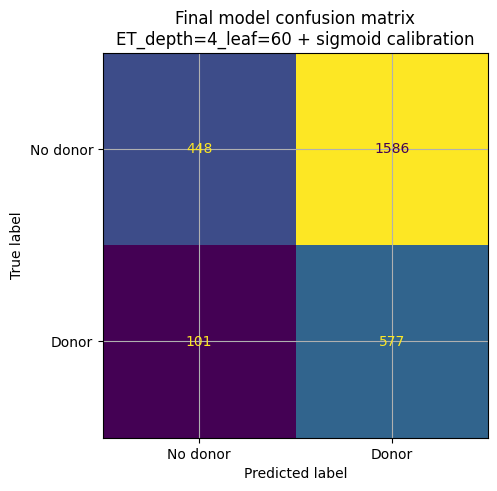

In [0]:
# Refit selected model on the full development partition only.
final_model = clone(final_estimator_template)
final_model.fit(X_dev, y_dev)

final_test_proba = final_model.predict_proba(X_test_internal)[:, 1]
final_test_pred = (final_test_proba >= final_threshold).astype(int)

print('Final internal-test metrics')
print('F1       :', round(f1_score(y_test_internal, final_test_pred, zero_division=0), 4))
print('Precision:', round(precision_score(y_test_internal, final_test_pred, zero_division=0), 4))
print('Recall   :', round(recall_score(y_test_internal, final_test_pred, zero_division=0), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test_internal, final_test_proba), 4))
print('\nClassification report:')
print(classification_report(y_test_internal, final_test_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_internal,
    final_test_pred,
    display_labels=['No donor', 'Donor'],
    colorbar=False,
    ax=ax
)
ax.set_title(f'Final model confusion matrix\n{final_model_name}')
plt.show()


## 13. Precision, Recall and F1 threshold curve for the final model

This plot explains the business trade-off. Lower thresholds increase Recall but can reduce Precision. Higher thresholds increase selectivity but can miss donors.


threshold,f1,precision,recall,predicted_positive_rate
0.2,0.4103,0.2756,0.8024,0.7279
0.19,0.4062,0.2668,0.851,0.7976
0.18,0.4039,0.2606,0.8968,0.8603
0.21,0.4026,0.2795,0.7198,0.6438
0.17,0.4018,0.2562,0.9307,0.9082
0.14,0.4015,0.2516,0.9941,0.9878
0.15,0.4013,0.252,0.9853,0.9775
0.13,0.4011,0.2508,1.0,0.9967
0.16,0.4004,0.2527,0.9631,0.9528
0.05,0.4,0.25,1.0,1.0


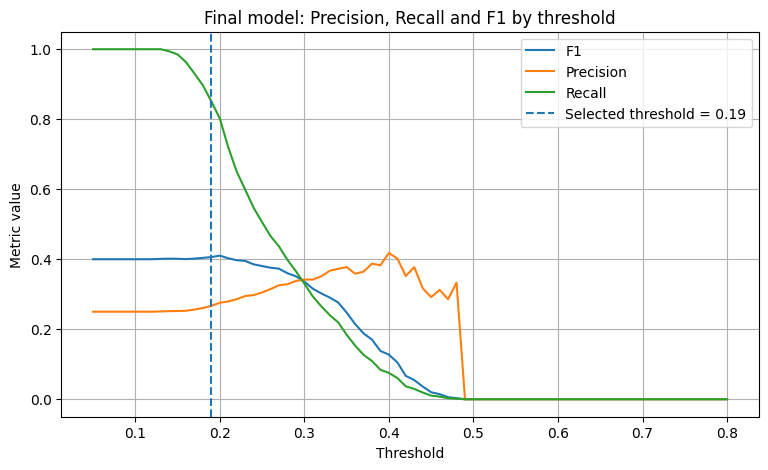

In [0]:
final_threshold_curve = threshold_table(y_test_internal, final_test_proba)

display(final_threshold_curve.sort_values('f1', ascending=False).head(10).round(4))

plt.figure(figsize=(9, 5))
plt.plot(final_threshold_curve['threshold'], final_threshold_curve['f1'], label='F1')
plt.plot(final_threshold_curve['threshold'], final_threshold_curve['precision'], label='Precision')
plt.plot(final_threshold_curve['threshold'], final_threshold_curve['recall'], label='Recall')
plt.axvline(final_threshold, linestyle='--', label=f'Selected threshold = {final_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('Final model: Precision, Recall and F1 by threshold')
plt.legend()
plt.show()


## 14. Overfitting diagnostic

A model is preferred only if it improves F1 without creating a large train-to-test or fit-to-OOF gap.


In [0]:
final_dev_proba = final_model.predict_proba(X_dev)[:, 1]
final_dev_pred = (final_dev_proba >= final_threshold).astype(int)

final_overfit_row = pd.DataFrame([{
    'model': final_model_name,
    'threshold': final_threshold,
    'dev_fit_f1': f1_score(y_dev, final_dev_pred, zero_division=0),
    'test_f1': f1_score(y_test_internal, final_test_pred, zero_division=0),
    'f1_fit_test_gap': f1_score(y_dev, final_dev_pred, zero_division=0) - f1_score(y_test_internal, final_test_pred, zero_division=0),
    'dev_fit_precision': precision_score(y_dev, final_dev_pred, zero_division=0),
    'test_precision': precision_score(y_test_internal, final_test_pred, zero_division=0),
    'dev_fit_recall': recall_score(y_dev, final_dev_pred, zero_division=0),
    'test_recall': recall_score(y_test_internal, final_test_pred, zero_division=0),
    'dev_fit_roc_auc': roc_auc_score(y_dev, final_dev_proba),
    'test_roc_auc': roc_auc_score(y_test_internal, final_test_proba),
    'auc_fit_test_gap': roc_auc_score(y_dev, final_dev_proba) - roc_auc_score(y_test_internal, final_test_proba)
}])

display(final_overfit_row.round(4))


model,threshold,dev_fit_f1,test_f1,f1_fit_test_gap,dev_fit_precision,test_precision,dev_fit_recall,test_recall,dev_fit_roc_auc,test_roc_auc,auc_fit_test_gap
ET_depth=4_leaf=60 + sigmoid calibration,0.19,0.4182,0.4062,0.012,0.2762,0.2668,0.8606,0.851,0.6242,0.5879,0.0363


## 15. Feature importance / model interpretation

For tree-based final models, impurity-based feature importance can be extracted after preprocessing. For linear models, coefficients can be inspected. This section is intentionally defensive because the final model may be a pipeline, a voting classifier or a calibrated model.


In [0]:
def get_feature_names_from_pipeline(pipe):
    try:
        preprocessor = pipe.named_steps['preprocessor']
        return preprocessor.get_feature_names_out()
    except Exception:
        return None

# Interpret the best single model when possible, because ensembles/calibrated wrappers are harder to inspect directly.
best_interpretable_name = best_single_name
best_interpretable_model = clone(tuned_candidates[best_interpretable_name]).fit(X_dev, y_dev)

try:
    feature_names = best_interpretable_model.named_steps['preprocessor'].get_feature_names_out()
    if 'feature_selector' in best_interpretable_model.named_steps:
        mask = best_interpretable_model.named_steps['feature_selector'].get_support()
        feature_names = feature_names[mask]

    model_step = best_interpretable_model.named_steps['model']
    if hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
        importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        importance_df = importance_df.sort_values('importance', ascending=False).head(30)
        display(importance_df)
    elif hasattr(model_step, 'coef_'):
        coefs = model_step.coef_.ravel()
        coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs, 'abs_coefficient': np.abs(coefs)})
        coef_df = coef_df.sort_values('abs_coefficient', ascending=False).head(30)
        display(coef_df)
    else:
        print('The selected interpretable model does not expose direct coefficients/importances.')
except Exception as e:
    print('Feature interpretation skipped:', e)


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run wistful-lynx-840 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/8d5f40ec808f4541a2ec0fea7f24f733
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876


feature,importance
cat__RECENCY_STATUS_96NK_S,0.0739201555147568
num__RECENT_CARD_RESPONSE_COUNT,0.07164453481155385
num__FREQUENCY_STATUS_97NK,0.05971348126456566
num__RECENT_RESPONSE_COUNT,0.05738262606323894
num__PEP_STAR,0.03952598133742486
num__RECENT_CARD_RESPONSE_PROP,0.039217183377614435
num__FILE_CARD_GIFT,0.039007089914073936
num__recent_response_x_frequency,0.03794798975783643
num__RECENT_RESPONSE_PROP,0.036052867134252285
num__recent_response_per_recency,0.0348628886137935


## 16. Optional: generate predictions for the independent test file

This cell only runs when `donors_test.csv` is available. The final model is refit on the full labeled training file before generating independent test predictions.


In [0]:
existing_test_path = next((p for p in TEST_PATH_CANDIDATES if os.path.exists(p)), None)

if existing_test_path is None:
    print('No independent donors_test.csv file found. Skipping submission generation.')
else:
    test_df_raw = pd.read_csv(existing_test_path)
    test_ids = test_df_raw[ID_COL].copy() if ID_COL in test_df_raw.columns else pd.Series(np.arange(len(test_df_raw)), name=ID_COL)

    X_full = clean_and_engineer_donors(train_df_raw.drop(columns=[TARGET, ID_COL], errors='ignore'))
    y_full = train_df_raw[TARGET].astype(int)
    X_kaggle = clean_and_engineer_donors(test_df_raw.drop(columns=[TARGET, ID_COL], errors='ignore'))

    # Align columns defensively. Missing columns in test are added as NaN; extra columns are ignored.
    for col in X_full.columns:
        if col not in X_kaggle.columns:
            X_kaggle[col] = np.nan
    X_kaggle = X_kaggle[X_full.columns]

    production_model = clone(final_estimator_template)
    production_model.fit(X_full, y_full)
    test_proba = production_model.predict_proba(X_kaggle)[:, 1]
    test_pred = (test_proba >= final_threshold).astype(int)

    submission = pd.DataFrame({
        ID_COL: test_ids,
        TARGET: test_pred,
        'TARGET_PROBA': test_proba
    })
    submission_path = 'submission_sklearn_f1_optimized.csv'
    submission.to_csv(submission_path, index=False)
    print('Saved:', submission_path)
    display(submission.head())


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run wise-mink-863 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876/runs/04b9d6c16187410b80a8d87116347b02
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1846244740221876
Saved: submission_sklearn_f1_optimized.csv


CONTROL_NUMBER,TARGET_B,TARGET_PROBA
122653,0,0.1833146662829889
184239,1,0.4459684490547417
5172,1,0.3005597875332921
135377,1,0.28325377918110156
62119,1,0.28083338333488506


# Final conclusions

This adapted version changes the project in three important ways:

1. **Predictive signal is increased** by using cleaned behavioral features, RFM-style interactions, response-rate variables, tenure variables and data-quality flags.
2. **F1-score optimization is more reliable** because thresholds are selected from out-of-fold probabilities instead of a single validation partition.
3. **Overfitting is reduced** by using conservative hyperparameter grids, regularized tree models, early stopping for histogram gradient boosting, optional feature selection, calibration checks and a selection score that penalizes fit-vs-OOF gap.

The final selected model should be interpreted as the best compromise between F1, Precision, Recall and generalization stability, not simply as the model with the highest score on one validation split.
